# Student Dropout Prediction - Model Training and Evaluation

This notebook implements the final preprocessing pipeline and classical model comparison based on the EDA findings. Dropout is the positive class, and recall/F1 are prioritized.

In [62]:
# Import libraries.
from pathlib import Path
import json
import warnings

warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    PrecisionRecallDisplay,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, TargetEncoder
from sklearn.svm import SVC

## Load Numeric MVP Dataset

The input file contains only the fixed MVP features, no `Enrolled` rows, and original numeric category codes.

In [63]:
# Resolve paths.
current_path = Path.cwd()

if (current_path / "data" / "processed" / "mvp_features_numeric.csv").exists():
    PROJECT_ROOT = current_path
else:
    PROJECT_ROOT = current_path.parent

MVP_NUMERIC_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "mvp_features_numeric.csv"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "processed.csv"
FEATURE_CONFIG_PATH = PROJECT_ROOT / "app" / "feature_config.json"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_PATH = MODEL_DIR / "final_mvp_model.pkl"
MODEL_PIPELINES_PATH = MODEL_DIR / "model_pipelines.pkl"
MVP_FEATURES_PATH = MODEL_DIR / "mvp_features.json"
MODEL_METADATA_PATH = MODEL_DIR / "model_metadata.json"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Numeric MVP data path:", MVP_NUMERIC_DATA_PATH)
print("Model directory:", MODEL_DIR)
print("Reports directory:", REPORTS_DIR)

Numeric MVP data path: e:\Projects\student-dropout-prediction-ml\data\processed\mvp_features_numeric.csv
Model directory: e:\Projects\student-dropout-prediction-ml\models
Reports directory: e:\Projects\student-dropout-prediction-ml\reports


In [64]:
# Load data and encode target.
df = pd.read_csv(MVP_NUMERIC_DATA_PATH)

with open(FEATURE_CONFIG_PATH, "r", encoding="utf-8") as file:
    feature_config = json.load(file)

candidate_mvp_features = feature_config["features"]

df["Target"] = df["Target"].map({"Graduate": 0, "Dropout": 1})

X = df[candidate_mvp_features].copy()
y = df["Target"].copy()

print("Dataset shape:", df.shape)
print("Target distribution:")
print(y.value_counts().sort_index())

df.head()

Dataset shape: (3630, 11)
Target distribution:
Target
0    2209
1    1421
Name: count, dtype: int64


,Marital status,Course,Previous qualification,Mother's qualification,Father's qualification,Displaced,Educational special needs,Gender,Age at enrollment,International,Target
0,1,2,1,13,10,1,0,1,20,0,1
1,1,11,1,1,3,1,0,1,19,0,0
2,1,5,1,22,27,1,0,1,19,0,1
3,1,15,1,23,27,1,0,0,20,0,0
4,2,3,1,22,28,0,0,0,45,0,0


## Feature Groups and Preprocessor

The transformations follow the EDA: binary flags pass through, age uses robust scaling, manageable nominal features use OHE, and high-cardinality parent qualification fields use cross-fitted target encoding.

In [65]:
# Define feature groups.
BINARY_FEATURES = [
    "Displaced",
    "Educational special needs",
    "Gender",
    "International"
]

CONTINUOUS_FEATURES = [
    "Age at enrollment"
]

OHE_FEATURES = [
    "Marital status",
    "Course",
    "Previous qualification"
]

TARGET_ENC_FEATURES = [
    "Mother's qualification",
    "Father's qualification"
]

feature_groups = {
    "binary_features": BINARY_FEATURES,
    "continuous_features": CONTINUOUS_FEATURES,
    "ohe_features": OHE_FEATURES,
    "target_encoded_features": TARGET_ENC_FEATURES
}

feature_groups

{'binary_features': ['Displaced',
  'Educational special needs',
  'Gender',
  'International'],
 'continuous_features': ['Age at enrollment'],
 'ohe_features': ['Marital status', 'Course', 'Previous qualification'],
 'target_encoded_features': ["Mother's qualification",
  "Father's qualification"]}

In [66]:
# Build preprocessing pipeline.
preprocessor = ColumnTransformer(
    transformers=[
        ("binary", "passthrough", BINARY_FEATURES),
        ("continuous", RobustScaler(), CONTINUOUS_FEATURES),
        (
            "ohe",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                drop="first"
            ),
            OHE_FEATURES
        ),
        (
            "target_enc",
            TargetEncoder(
                target_type="binary",
                smooth="auto",
                cv=5,
                random_state=42
            ),
            TARGET_ENC_FEATURES
        ),
    ],
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('binary', ...), ('continuous', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

## Classical Model Set

All models are classical ML models. Class balancing is used where supported because Dropout recall is the priority.

In [67]:
# Define models.
models = {
    "Logistic Regression": LogisticRegression(
        C=0.5,
        penalty="l2",
        solver="saga",
        class_weight="balanced",
        max_iter=2000,
        random_state=42,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=4,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        min_samples_leaf=10,
        random_state=42,
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=400,
        min_samples_leaf=4,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    ),
    "SVM (RBF)": SVC(
        C=1.0,
        kernel="rbf",
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=42,
    ),
}

list(models.keys())

['Logistic Regression',
 'Random Forest',
 'Gradient Boosting',
 'Extra Trees',
 'SVM (RBF)']

## 5-Fold Stratified Cross-Validation

The main comparison uses recall, precision, F1-score, and ROC-AUC with Dropout as the positive class.

In [68]:
# Evaluate models with 5-fold stratified CV.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "recall": make_scorer(recall_score, pos_label=1),
    "precision": make_scorer(precision_score, pos_label=1, zero_division=0),
    "f1": make_scorer(f1_score, pos_label=1),
    "roc_auc": "roc_auc",
}

cv_raw_results = {}
summary_rows = []

for model_name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", clone(model))
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=1,
    )

    cv_raw_results[model_name] = {
        key: value for key, value in scores.items()
        if key.startswith("test_")
    }

    summary_rows.append({
        "Model": model_name,
        "Recall": scores["test_recall"].mean(),
        "Precision": scores["test_precision"].mean(),
        "F1-Score": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
    })

cv_results_df = (
    pd.DataFrame(summary_rows)
    .sort_values(["F1-Score", "ROC-AUC"], ascending=False)
    .reset_index(drop=True)
)

cv_results_df.to_csv(REPORTS_DIR / "validation_model_comparison.csv", index=False)
cv_results_df

,Model,Recall,Precision,F1-Score,ROC-AUC
0,Random Forest,0.684018,0.614097,0.646961,0.770142
1,Extra Trees,0.690346,0.598666,0.641110,0.764351
2,SVM (RBF),0.683328,0.598363,0.637834,0.762086
3,Logistic Regression,0.665725,0.610084,0.636504,0.758786
4,Gradient Boosting,0.562278,0.664644,0.608810,0.765943


## Holdout Split and Threshold Tuning

A stratified holdout split is used to inspect thresholds. Random Forest at threshold `0.40` is selected because it gives much higher Dropout recall while preserving F1-score.

In [69]:
# Create one stratified holdout split for threshold analysis and final reporting.
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(X, y))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

thresholds = [0.50, 0.40, 0.35]
threshold_model_names = ["Random Forest", "Gradient Boosting", "Logistic Regression"]
threshold_rows = []
holdout_pipelines = {}
holdout_probabilities = {}
holdout_predictions = {}

for model_name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", clone(model))
    ])

    pipeline.fit(X_train, y_train)
    holdout_pipelines[model_name] = pipeline

    proba = pipeline.predict_proba(X_test)[:, 1]
    preds = (proba >= 0.50).astype(int)
    holdout_probabilities[model_name] = proba
    holdout_predictions[model_name] = preds

    if model_name in threshold_model_names:
        for threshold in thresholds:
            threshold_preds = (proba >= threshold).astype(int)
            threshold_rows.append({
                "Model": model_name,
                "Threshold": threshold,
                "Recall": recall_score(y_test, threshold_preds, pos_label=1),
                "Precision": precision_score(y_test, threshold_preds, pos_label=1, zero_division=0),
                "F1-Score": f1_score(y_test, threshold_preds, pos_label=1),
                "ROC-AUC": roc_auc_score(y_test, proba),
            })

threshold_results_df = pd.DataFrame(threshold_rows)
threshold_results_df.to_csv(REPORTS_DIR / "threshold_tuning_results.csv", index=False)
threshold_results_df

,Model,Threshold,Recall,Precision,F1-Score,ROC-AUC
0,Logistic Regression,0.50,0.718310,0.603550,0.655949,0.765172
1,Logistic Regression,0.40,0.848592,0.533186,0.654891,0.765172
2,Logistic Regression,0.35,0.897887,0.492278,0.635910,0.765172
3,Random Forest,0.50,0.690141,0.601227,0.642623,0.775265
4,Random Forest,0.40,0.838028,0.537246,0.654746,0.775265
5,Random Forest,0.35,0.887324,0.509091,0.646983,0.775265
6,Gradient Boosting,0.50,0.559859,0.646341,0.600000,0.760862
7,Gradient Boosting,0.40,0.669014,0.590062,0.627063,0.760862
8,Gradient Boosting,0.35,0.739437,0.581717,0.651163,0.760862


In [70]:
# Select final model and threshold.
best_model_name = "Random Forest"
best_threshold = 0.40

print("Best model:", best_model_name)
print("Decision threshold:", best_threshold)

Best model: Random Forest
Decision threshold: 0.4


## Final Holdout Evaluation

The final reported model is Random Forest with threshold `0.40`. Probability scores are still retained for confidence display and ROC-AUC.

In [71]:
# Evaluate final model on the holdout set using the selected threshold.
final_pipeline = holdout_pipelines[best_model_name]
final_proba = final_pipeline.predict_proba(X_test)[:, 1]
final_preds = (final_proba >= best_threshold).astype(int)

final_evaluation_df = pd.DataFrame([{
    "Model": best_model_name,
    "Threshold": best_threshold,
    "Accuracy": (final_preds == y_test).mean(),
    "Precision": precision_score(y_test, final_preds, pos_label=1, zero_division=0),
    "Recall": recall_score(y_test, final_preds, pos_label=1),
    "F1-Score": f1_score(y_test, final_preds, pos_label=1),
    "ROC-AUC": roc_auc_score(y_test, final_proba),
}])

final_evaluation_df.to_csv(REPORTS_DIR / "final_model_evaluation.csv", index=False)

print("Confusion matrix:")
print(confusion_matrix(y_test, final_preds))
print("\nClassification report:")
print(classification_report(y_test, final_preds, target_names=["Graduate", "Dropout"]))

final_evaluation_df

Confusion matrix:
[[237 205]
 [ 46 238]]

Classification report:
              precision    recall  f1-score   support

    Graduate       0.84      0.54      0.65       442
     Dropout       0.54      0.84      0.65       284

    accuracy                           0.65       726
   macro avg       0.69      0.69      0.65       726
weighted avg       0.72      0.65      0.65       726



,Model,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.4,0.65427,0.537246,0.838028,0.654746,0.775265


In [72]:
# Save classification report tables for the key holdout models.
classification_report_rows = []

for model_name in threshold_model_names:
    proba = holdout_probabilities[model_name]
    threshold = best_threshold if model_name == best_model_name else 0.50
    preds = (proba >= threshold).astype(int)

    report = classification_report(
        y_test,
        preds,
        target_names=["Graduate", "Dropout"],
        output_dict=True,
        zero_division=0
    )

    for label in ["Graduate", "Dropout"]:
        classification_report_rows.append({
            "Model": model_name,
            "Threshold": threshold,
            "Class": label,
            "Precision": report[label]["precision"],
            "Recall": report[label]["recall"],
            "F1-Score": report[label]["f1-score"],
            "Support": report[label]["support"],
        })

classification_report_df = pd.DataFrame(classification_report_rows)
classification_report_df.to_csv(REPORTS_DIR / "validation_classification_report.csv", index=False)
classification_report_df

,Model,Threshold,Class,Precision,Recall,F1-Score,Support
0,Random Forest,0.4,Graduate,0.837456,0.536199,0.653793,442.0
1,Random Forest,0.4,Dropout,0.537246,0.838028,0.654746,284.0
2,Gradient Boosting,0.5,Graduate,0.739583,0.803167,0.770065,442.0
3,Gradient Boosting,0.5,Dropout,0.646341,0.559859,0.600000,284.0
4,Logistic Regression,0.5,Graduate,0.793814,0.696833,0.742169,442.0
5,Logistic Regression,0.5,Dropout,0.603550,0.718310,0.655949,284.0


## Feature Importance

Tree-based importances are inspected for Random Forest and Gradient Boosting. This is for interpretation, not feature selection.

In [73]:
# Helper to recover transformed feature names.
def get_feature_names(column_transformer):
    names = []

    for transformer_name, transformer, columns in column_transformer.transformers_:
        if transformer == "passthrough":
            names.extend(columns)
        elif hasattr(transformer, "get_feature_names_out"):
            names.extend(transformer.get_feature_names_out(columns))
        else:
            names.extend(columns)

    return names

feature_importance_tables = {}

for model_name in ["Random Forest", "Gradient Boosting", "Extra Trees"]:
    pipeline = holdout_pipelines[model_name]
    feature_names = get_feature_names(pipeline.named_steps["preprocessor"])
    importances = pipeline.named_steps["model"].feature_importances_

    importance_df = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    feature_importance_tables[model_name] = importance_df

rf_feature_importance_df = feature_importance_tables["Random Forest"]
extra_trees_feature_importance_df = feature_importance_tables["Extra Trees"]

rf_feature_importance_df.to_csv(REPORTS_DIR / "final_feature_importance.csv", index=False)
extra_trees_feature_importance_df.to_csv(REPORTS_DIR / "extra_trees_feature_importance.csv", index=False)

rf_feature_importance_df.head(15)


,feature,importance
0,Age at enrollment,0.274892
1,Mother's qualification,0.121576
2,Father's qualification,0.115439
3,Gender,0.111903
4,Course_12,0.086951
5,Course_7,0.038278
6,Course_10,0.027720
7,Course_16,0.025735
8,Displaced,0.022952
9,Course_3,0.015294


## Visual Reports

Save individual plots for the app plus one combined comparison chart for reporting.

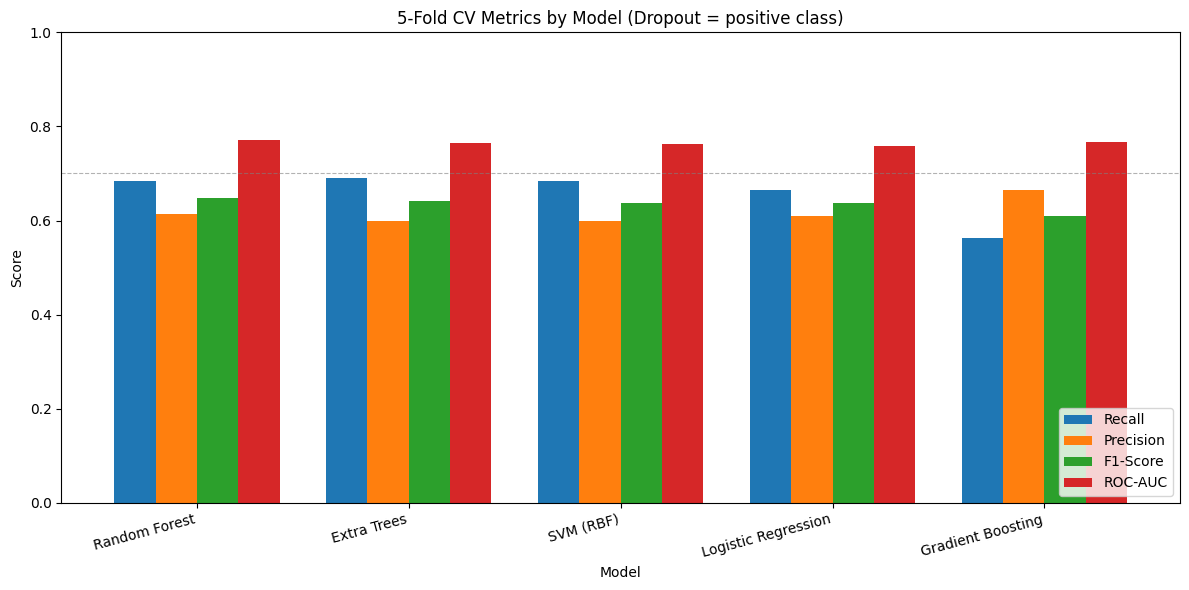

In [74]:
# Plot CV metrics comparison.
metrics_df = cv_results_df.set_index("Model")[["Recall", "Precision", "F1-Score", "ROC-AUC"]]

fig, ax = plt.subplots(figsize=(12, 6))
metrics_df.plot(kind="bar", ax=ax, width=0.78)
ax.set_title("5-Fold CV Metrics by Model (Dropout = positive class)")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.axhline(0.7, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.legend(loc="lower right")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "validation_metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

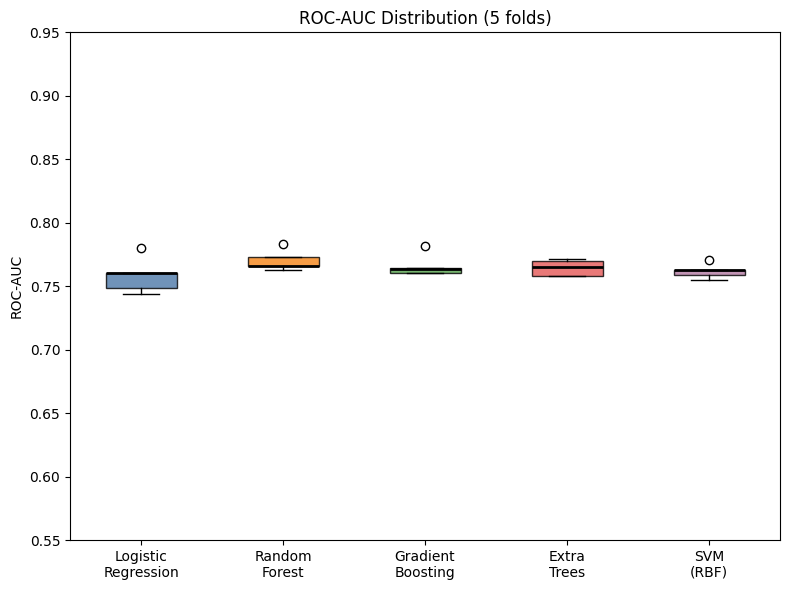

In [75]:
# Plot ROC-AUC fold distribution.
roc_data = {model_name: values["test_roc_auc"] for model_name, values in cv_raw_results.items()}

fig, ax = plt.subplots(figsize=(8, 6))
box = ax.boxplot(
    roc_data.values(),
    labels=[name.replace(" ", "\n") for name in roc_data.keys()],
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 2},
)

palette = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#B279A2"]
for patch, color in zip(box["boxes"], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_ylabel("ROC-AUC")
ax.set_title("ROC-AUC Distribution (5 folds)")
ax.set_ylim(0.55, 0.95)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "validation_roc_curve_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

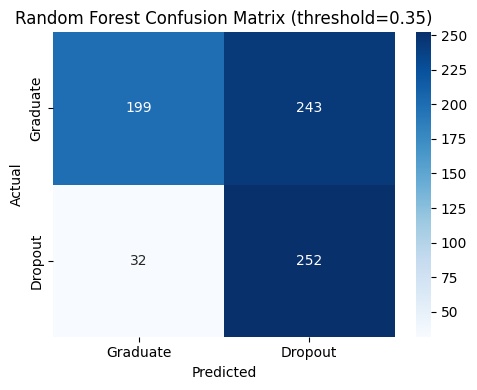

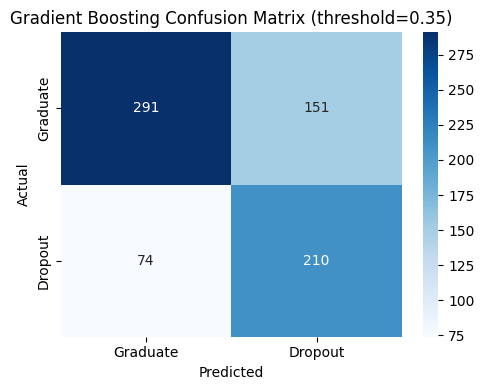

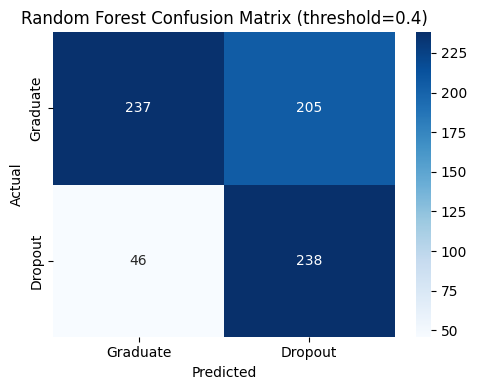

In [76]:
# Plot confusion matrices for Random Forest and Gradient Boosting at threshold 0.35 plus final RF at 0.40.
confusion_plot_specs = [
    ("Random Forest", 0.35, "validation_confusion_matrix_random_forest.png"),
    ("Gradient Boosting", 0.35, "validation_confusion_matrix_gradient_boosting.png"),
    ("Random Forest", best_threshold, "final_test_confusion_matrix.png"),
]

for model_name, threshold, filename in confusion_plot_specs:
    proba = holdout_pipelines[model_name].predict_proba(X_test)[:, 1]
    preds = (proba >= threshold).astype(int)
    matrix = confusion_matrix(y_test, preds)

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Graduate", "Dropout"],
        yticklabels=["Graduate", "Dropout"],
    )
    ax.set_title(f"{model_name} Confusion Matrix (threshold={threshold})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

### Confusion Matrix for All Models

This plot compares default-threshold holdout predictions for every model, so false positives and false negatives can be inspected model by model.

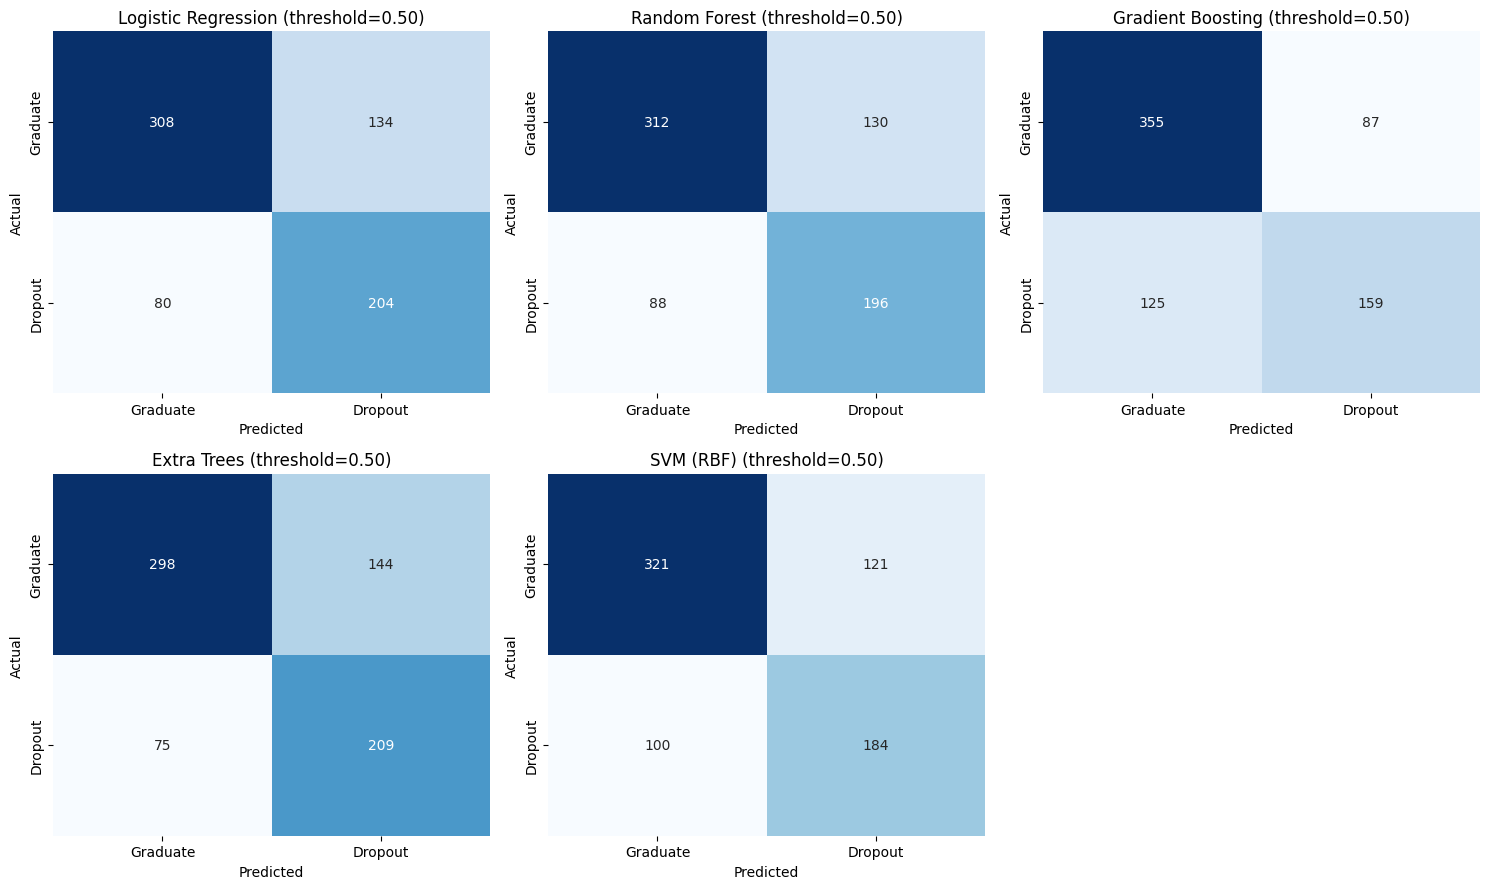

In [77]:
# Plot confusion matrix for every model at default threshold 0.50.
model_names = list(models.keys())
cols = 3
rows = int(np.ceil(len(model_names) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 4.5 * rows))
axes = np.array(axes).reshape(-1)

for ax, model_name in zip(axes, model_names):
    matrix = confusion_matrix(y_test, holdout_predictions[model_name])
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Graduate", "Dropout"],
        yticklabels=["Graduate", "Dropout"],
        cbar=False,
    )
    ax.set_title(f"{model_name} (threshold=0.50)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

for ax in axes[len(model_names):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "holdout_confusion_matrix_all_models.png", dpi=150, bbox_inches="tight")
plt.show()


### ROC Curve Comparison for All Models

ROC curves compare how well each model separates Graduate and Dropout across thresholds.

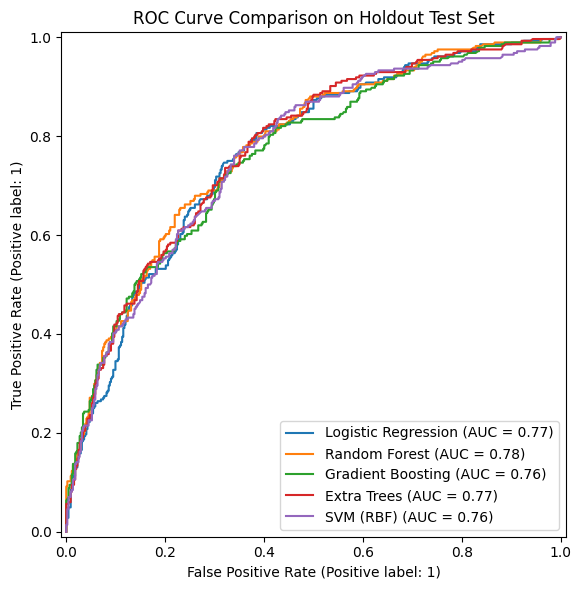

In [78]:
# Plot ROC curve comparison for every holdout model.
fig, ax = plt.subplots(figsize=(7, 6))

for model_name in model_names:
    RocCurveDisplay.from_predictions(
        y_test,
        holdout_probabilities[model_name],
        name=model_name,
        ax=ax,
    )

ax.set_title("ROC Curve Comparison on Holdout Test Set")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "holdout_roc_curve_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### Precision-Recall Curve Comparison for All Models

Precision-recall curves are useful because this project prioritizes finding students who may be at dropout risk.

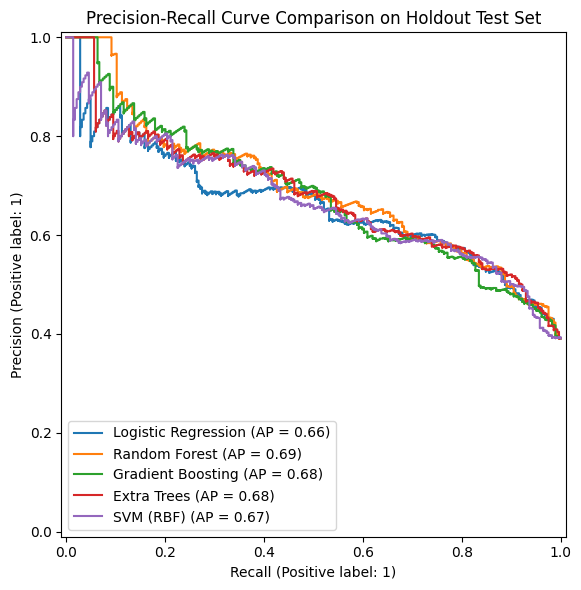

In [79]:
# Plot precision-recall curve comparison for every holdout model.
fig, ax = plt.subplots(figsize=(7, 6))

for model_name in model_names:
    PrecisionRecallDisplay.from_predictions(
        y_test,
        holdout_probabilities[model_name],
        name=model_name,
        ax=ax,
    )

ax.set_title("Precision-Recall Curve Comparison on Holdout Test Set")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "holdout_precision_recall_curve_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### Random Forest Threshold Sweep

This plot shows how the Random Forest trade-off changes as the Dropout decision threshold moves.

In [80]:
# Sweep Random Forest thresholds to inspect recall, precision, F1, and accuracy trade-offs.
rf_proba = holdout_probabilities[best_model_name]
threshold_sweep_values = np.arange(0.20, 0.71, 0.05)
threshold_sweep_rows = []

for threshold in threshold_sweep_values:
    preds = (rf_proba >= threshold).astype(int)
    threshold_sweep_rows.append({
        "Threshold": round(float(threshold), 2),
        "Accuracy": (preds == y_test).mean(),
        "Precision": precision_score(y_test, preds, pos_label=1, zero_division=0),
        "Recall": recall_score(y_test, preds, pos_label=1),
        "F1-Score": f1_score(y_test, preds, pos_label=1),
        "ROC-AUC": roc_auc_score(y_test, rf_proba),
    })

threshold_sweep_df = pd.DataFrame(threshold_sweep_rows)
threshold_sweep_df.to_csv(REPORTS_DIR / "random_forest_threshold_sweep.csv", index=False)
threshold_sweep_df


,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,0.20,0.476584,0.426829,0.985915,0.595745,0.775265
1,0.25,0.545455,0.460616,0.947183,0.619816,0.775265
2,0.30,0.577135,0.478664,0.908451,0.626974,0.775265
3,0.35,0.621212,0.509091,0.887324,0.646983,0.775265
4,0.40,0.654270,0.537246,0.838028,0.654746,0.775265
5,0.45,0.688705,0.574742,0.785211,0.663690,0.775265
6,0.50,0.699725,0.601227,0.690141,0.642623,0.775265
7,0.55,0.719008,0.651515,0.605634,0.627737,0.775265
8,0.60,0.707989,0.676471,0.485915,0.565574,0.775265
9,0.65,0.707989,0.722222,0.411972,0.524664,0.775265


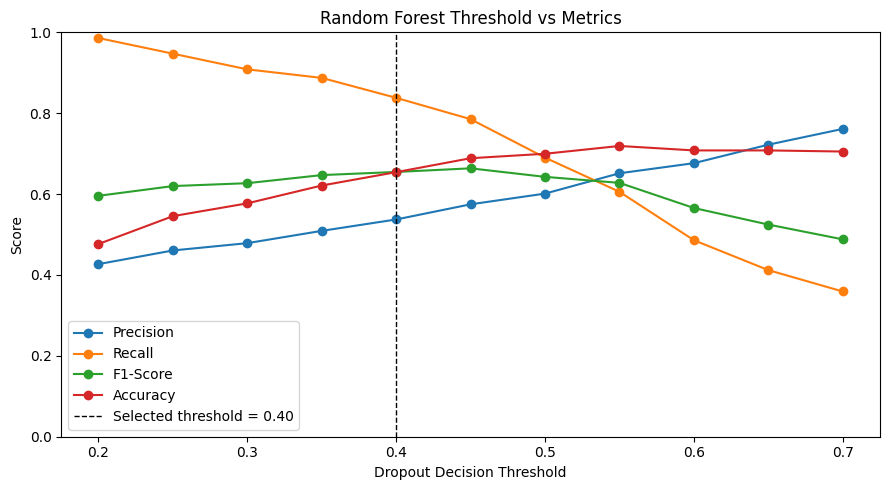

In [81]:
# Plot threshold against core metrics for Random Forest.
fig, ax = plt.subplots(figsize=(9, 5))

for metric in ["Precision", "Recall", "F1-Score", "Accuracy"]:
    ax.plot(
        threshold_sweep_df["Threshold"],
        threshold_sweep_df[metric],
        marker="o",
        label=metric,
    )

ax.axvline(best_threshold, color="black", linestyle="--", linewidth=1, label=f"Selected threshold = {best_threshold:.2f}")
ax.set_title("Random Forest Threshold vs Metrics")
ax.set_xlabel("Dropout Decision Threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "random_forest_threshold_sweep.png", dpi=150, bbox_inches="tight")
plt.show()


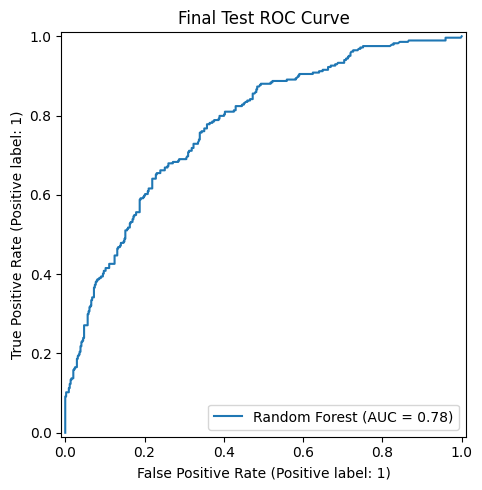

In [82]:
# Plot final ROC curve manually for Random Forest.
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test,
    final_proba,
    name=f"{best_model_name}",
    ax=ax
)
ax.set_title("Final Test ROC Curve")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_test_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

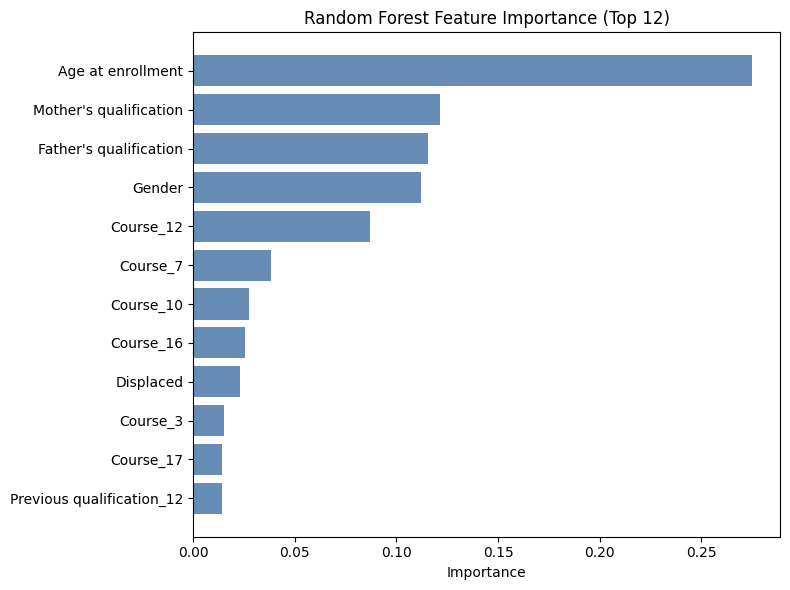

In [83]:
# Plot Random Forest feature importance.
rf_top_features = rf_feature_importance_df.head(12).sort_values("importance")

def clean_feature_name(name):
    for prefix in ["binary__", "continuous__", "ohe__", "target_enc__"]:
        name = name.replace(prefix, "")
    return name[:35]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    [clean_feature_name(name) for name in rf_top_features["feature"]],
    rf_top_features["importance"],
    color="#4C78A8",
    alpha=0.85
)
ax.set_title("Random Forest Feature Importance (Top 12)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

### Extra Trees Feature Importance

Extra Trees is another tree ensemble, so its feature importance helps compare whether the same predictors remain influential across tree-based models.

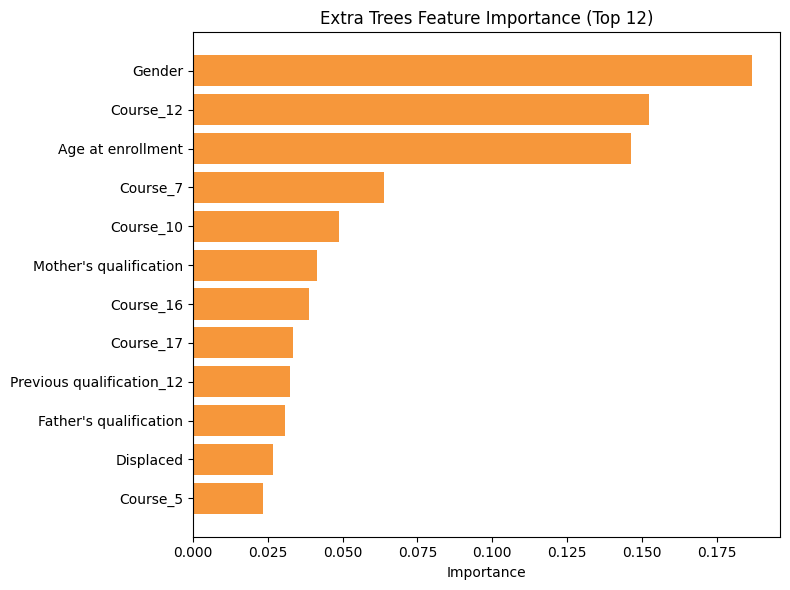

In [84]:
# Plot Extra Trees feature importance.
extra_top_features = extra_trees_feature_importance_df.head(12).sort_values("importance")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    [clean_feature_name(name) for name in extra_top_features["feature"]],
    extra_top_features["importance"],
    color="#F58518",
    alpha=0.85,
)
ax.set_title("Extra Trees Feature Importance (Top 12)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "extra_trees_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


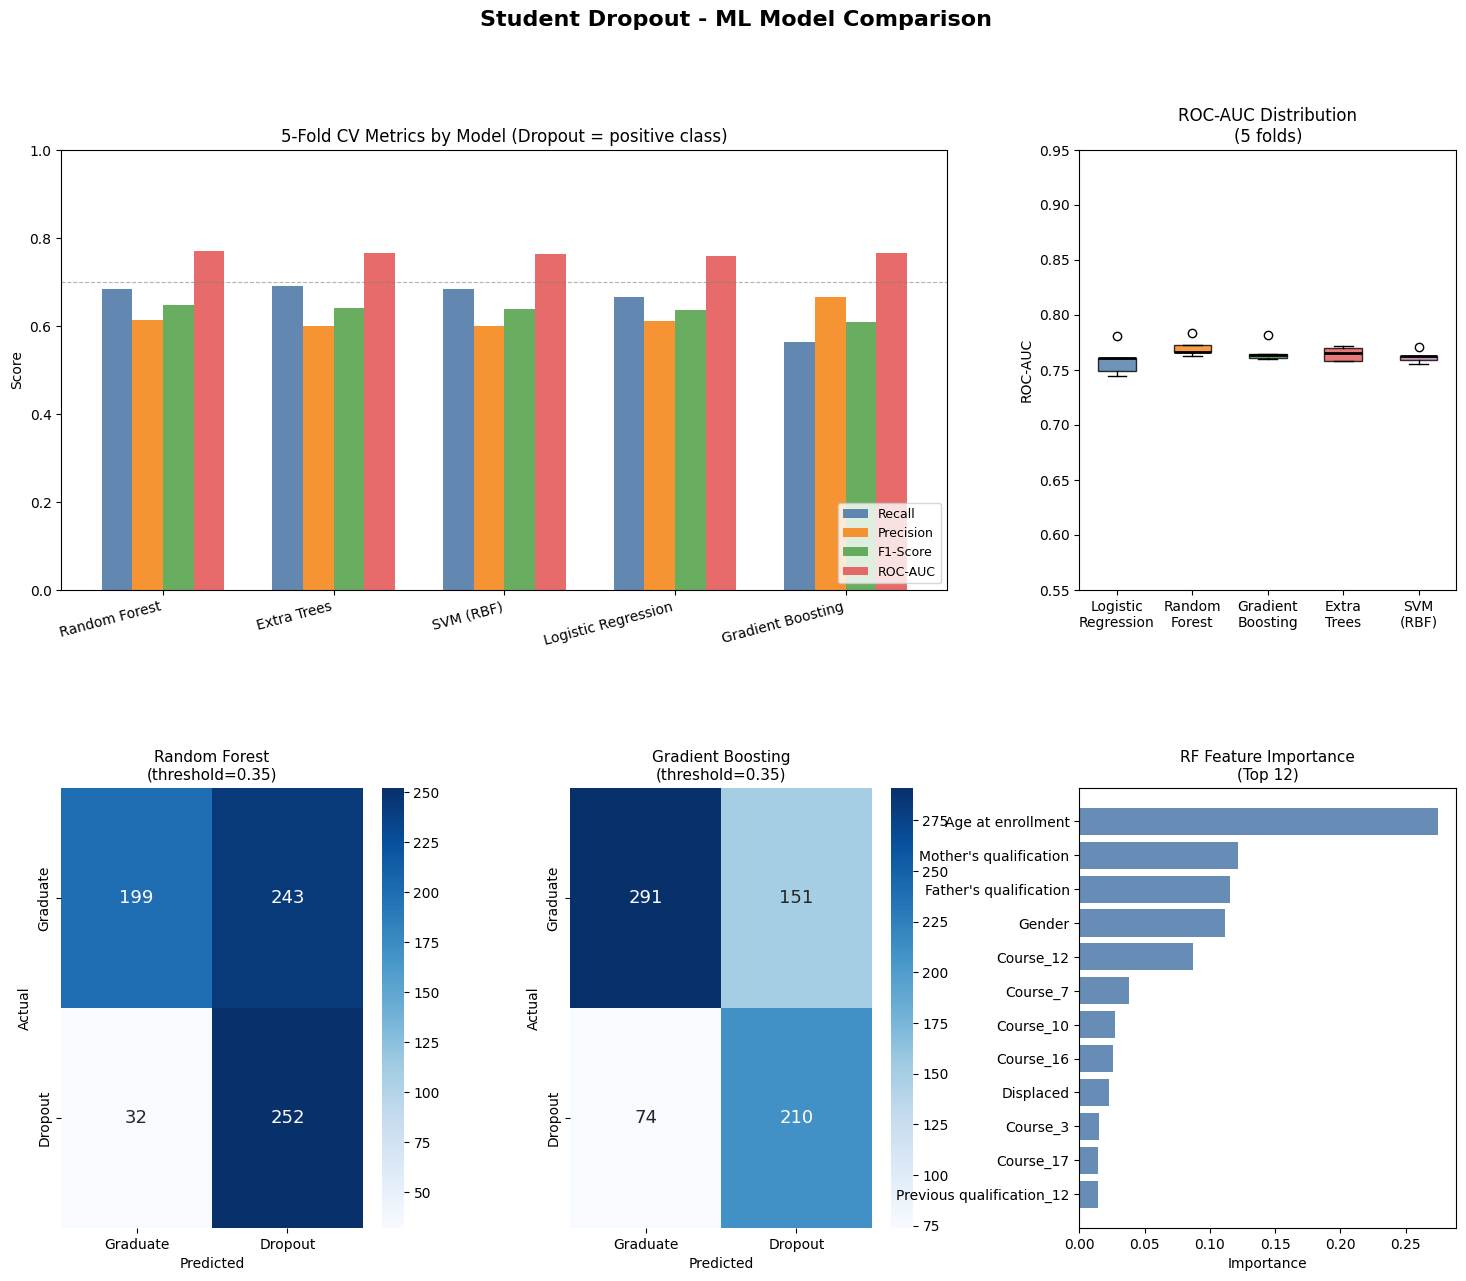

In [85]:
# Build combined report figure.
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Student Dropout - ML Model Comparison", fontsize=16, fontweight="bold", y=0.98)
grid = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(grid[0, :2])
x = np.arange(len(metrics_df))
width = 0.18
colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]
for index, (metric, color) in enumerate(zip(metrics_df.columns, colors)):
    ax1.bar(x + index * width, metrics_df[metric], width, label=metric, color=color, alpha=0.88)
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(metrics_df.index, rotation=15, ha="right", fontsize=10)
ax1.set_ylabel("Score")
ax1.set_ylim(0, 1.0)
ax1.set_title("5-Fold CV Metrics by Model (Dropout = positive class)")
ax1.legend(loc="lower right", fontsize=9)
ax1.axhline(0.7, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

ax2 = fig.add_subplot(grid[0, 2])
box = ax2.boxplot(
    roc_data.values(),
    labels=[name.replace(" ", "\n") for name in roc_data.keys()],
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 2},
)
for patch, color in zip(box["boxes"], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax2.set_ylabel("ROC-AUC")
ax2.set_title("ROC-AUC Distribution\n(5 folds)")
ax2.set_ylim(0.55, 0.95)

for index, model_name in enumerate(["Random Forest", "Gradient Boosting"]):
    ax = fig.add_subplot(grid[1, index])
    proba = holdout_pipelines[model_name].predict_proba(X_test)[:, 1]
    preds = (proba >= 0.35).astype(int)
    matrix = confusion_matrix(y_test, preds)
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Graduate", "Dropout"],
        yticklabels=["Graduate", "Dropout"],
        annot_kws={"size": 13},
    )
    ax.set_title(f"{model_name}\n(threshold=0.35)", fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

ax5 = fig.add_subplot(grid[1, 2])
ax5.barh(
    [clean_feature_name(name) for name in rf_top_features["feature"]],
    rf_top_features["importance"],
    color="#4C78A8",
    alpha=0.85,
)
ax5.set_title("RF Feature Importance\n(Top 12)", fontsize=11)
ax5.set_xlabel("Importance")

plt.savefig(FIGURES_DIR / "ml_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Save Final Artifacts

The app loads all final model pipelines and applies the selected threshold from metadata. Random Forest is marked as the best model.

In [86]:
# Train final pipelines on all available data and save artifacts.
final_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", clone(model))
    ])
    pipeline.fit(X, y)
    final_pipelines[model_name] = pipeline

MODEL_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(final_pipelines[best_model_name], MODEL_PATH)
joblib.dump(final_pipelines, MODEL_PIPELINES_PATH)

with open(MVP_FEATURES_PATH, "w", encoding="utf-8") as file:
    json.dump(candidate_mvp_features, file, indent=4)

model_thresholds = {model_name: 0.50 for model_name in models}
model_thresholds[best_model_name] = best_threshold

model_metadata = {
    "model_name": "Final Student Dropout Prediction Model",
    "base_model": best_model_name,
    "best_model": best_model_name,
    "available_models": list(final_pipelines.keys()),
    "model_pipelines_path": "models/model_pipelines.pkl",
    "target_mapping": {
        "Graduate": 0,
        "Dropout": 1
    },
    "positive_class": "Dropout",
    "positive_class_value": 1,
    "decision_threshold": best_threshold,
    "model_thresholds": model_thresholds,
    "mvp_feature_count": len(candidate_mvp_features),
    "mvp_features": candidate_mvp_features,
    "feature_groups": feature_groups,
    "selection_metric": "Dropout F1-score with recall-first threshold tuning",
    "cv_results": cv_results_df.to_dict(orient="records"),
    "threshold_results": threshold_results_df.to_dict(orient="records"),
    "evaluation": final_evaluation_df.to_dict(orient="records"),
}

with open(MODEL_METADATA_PATH, "w", encoding="utf-8") as file:
    json.dump(model_metadata, file, indent=4)

print("Best model saved:", MODEL_PATH.exists())
print("Selectable model pipelines saved:", MODEL_PIPELINES_PATH.exists())
print("Model metadata saved:", MODEL_METADATA_PATH.exists())
model_metadata

Best model saved: True
Selectable model pipelines saved: True
Model metadata saved: True


{'model_name': 'Final Student Dropout Prediction Model',
 'base_model': 'Random Forest',
 'best_model': 'Random Forest',
 'available_models': ['Logistic Regression',
  'Random Forest',
  'Gradient Boosting',
  'Extra Trees',
  'SVM (RBF)'],
 'model_pipelines_path': 'models/model_pipelines.pkl',
 'target_mapping': {'Graduate': 0, 'Dropout': 1},
 'positive_class': 'Dropout',
 'positive_class_value': 1,
 'decision_threshold': 0.4,
 'model_thresholds': {'Logistic Regression': 0.5,
  'Random Forest': 0.4,
  'Gradient Boosting': 0.5,
  'Extra Trees': 0.5,
  'SVM (RBF)': 0.5},
 'mvp_feature_count': 10,
 'mvp_features': ['Marital status',
  'Course',
  'Previous qualification',
  "Mother's qualification",
  "Father's qualification",
  'Displaced',
  'Educational special needs',
  'Gender',
  'Age at enrollment',
  'International'],
 'feature_groups': {'binary_features': ['Displaced',
   'Educational special needs',
   'Gender',
   'International'],
  'continuous_features': ['Age at enrollment'

## Modeling Summary

- Random Forest is the primary model.
- Threshold `0.40` is used for Random Forest to improve Dropout recall.
- Logistic Regression remains useful as an interpretable baseline.
- Extra Trees, SVM, and Gradient Boosting are included for comparison.
- Feature importance confirms that age, parents' qualification, gender, and course carry strong signal.